# Mathematical Foundations for Linear Regression

This notebook covers the essential mathematical concepts required for understanding Linear Regression.

## Topics Covered:
1. Linear Algebra Basics
2. Statistics Fundamentals
3. Calculus Concepts

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


## 1. Linear Algebra Basics

### 1.1 Vectors and Matrices

In [18]:
# Creating vectors
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
print(x)

# Demonstrating dot product (important for linear regression)
dot_product = np.dot(x, y)
print(f"Dot product of x and y: {dot_product}")

# Creating a matrix
X = np.column_stack((np.ones_like(x), x)) # Design matrix with intercept
print("\nDesign matrix X:")
print(X)

[1 2 3 4 5]
Dot product of x and y: 110

Design matrix X:
[[1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]]


### 1.2 Matrix Operations for Linear Regression

The formula for Linear Regression coefficients using matrix notation:
β = (X'X)^(-1)X'y

In [19]:
# Computing β using matrix operations
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print("Linear Regression coefficients (β):")
print(f"Intercept: {beta[0]:.2f}")
print(f"Slope: {beta[1]:.2f}")

Linear Regression coefficients (β):
Intercept: 0.00
Slope: 2.00


In [30]:

import numpy as np

# Small example with 3 observations
y = np.array([2, 4, 6])  # Actual values
y_pred = np.array([1.5, 3.8, 5.5])  # Predicted values

# Calculate error vector
error = y - y_pred  # array([0.5, 0.2, 0.5])


# Method 1: Using matrix multiplication
mse_matrix = (1/3) * (error.T @ error)


# Method 2: Traditional MSE formula
mse_traditional = (1/3) * np.sum((y - y_pred)**2)

print(f"MSE using matrix form: {mse_matrix}")

print(f"MSE using traditional form: {mse_traditional}")
# Both will give the same result

MSE using matrix form: 0.18
MSE using traditional form: 0.18


## 2. Statistics Fundamentals

### 2.1 Mean, Variance, and Covariance

In [12]:
# Calculate basic statistics
mean_x = np.mean(x)
var_x = np.var(x)
cov_xy = np.cov(x, y)[0,1]

print(f"Mean of x: {mean_x:.2f}")
print(f"Variance of x: {var_x:.2f}")
print(f"Covariance between x and y: {cov_xy:.2f}")

Mean of x: 3.00
Variance of x: 2.00
Covariance between x and y: 5.00


### 2.2 Correlation

In [ ]:
# Calculate correlation coefficient
correlation = np.corrcoef(x, y)[0,1]

plt.figure(figsize=(10, 6))
plt.scatter(x, y)
plt.title(f'Correlation between x and y: {correlation:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

## 3. Calculus Concepts

### 3.1 Derivatives and Gradient Descent

The core of linear regression optimization involves minimizing the Mean Squared Error (MSE) using derivatives:

Initial parameters:  [0. 0.]
Iteration 1
[0. 0. 0. 0. 0.]
[ 2  4  6  8 10]
MSE: 44.0
[-12. -44.]
Updated parameters: [0.12 0.44]
Iteration 2
[0.56 1.   1.44 1.88 2.32]
[ 2  4  6  8 10]
MSE: 25.660800000000002
[ -9.12 -33.6 ]
Updated parameters: [0.2112 0.776 ]
Iteration 3
[0.9872 1.7632 2.5392 3.3152 4.0912]
[ 2  4  6  8 10]
MSE: 14.97348864
[ -6.9216 -25.6608]
Updated parameters: [0.280416 1.032608]
Iteration 4
[1.313024 2.345632 3.37824  4.410848 5.443456]
[ 2  4  6  8 10]
MSE: 8.745320060928002
[ -5.24352  -19.600128]
Updated parameters: [0.3328512  1.22860928]
Iteration 5
[1.56146048 2.79006976 4.01867904 5.24728832 6.4758976 ]
[ 2  4  6  8 10]
MSE: 5.115720032339558
[ -3.96264192 -14.97348864]
Updated parameters: [0.37247762 1.37834417]
Iteration 6
[1.75082179 3.12916595 4.50751012 5.88585428 7.26419845]
[ 2  4  6  8 10]
MSE: 3.000437997576207
[ -2.98497976 -11.44156262]
Updated parameters: [0.40232742 1.49275979]
Iteration 7
[1.89508721 3.387847   4.88060679 6.37336659 7.86612638

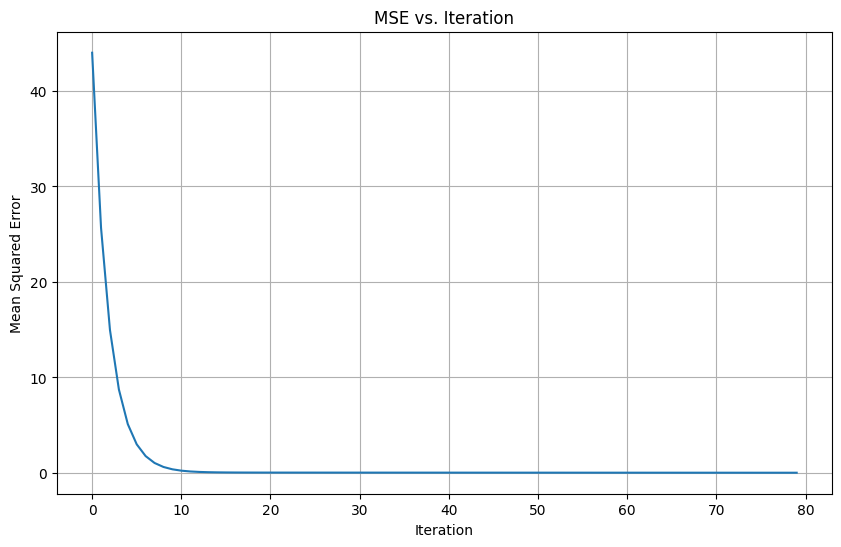

In [25]:
from tkinter import Y


def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_gradient(X, y, beta):
    y_pred = X @ beta
    return -2 * X.T @ (y - y_pred) / len(y)

# Demonstrate gradient descent
learning_rate = 0.01
n_iterations = 80
beta = np.zeros(2)  # Initialize parameters bias and slope 
print("Initial parameters: ", beta)
mse_history = []
for i in range(n_iterations):
    print(f"Iteration {i+1}")
    y_pred = X @ beta
    print(y_pred)
    print(y)
    mse = compute_mse(y, y_pred)
    mse_history.append(mse)
    print(f"MSE: {mse}")
    
    gradient = compute_gradient(X, y, beta)
    print(gradient)
    beta = beta - learning_rate * gradient
    
    # print updated parameters
    print(f"Updated parameters: {beta}")

plt.figure(figsize=(10, 6))
plt.plot(mse_history)
plt.title('MSE vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()